# LLM-based TTS

# Agenda
1. [TortoiseTTS](#TortoiseTTS)
1. [Overview](#overview-of-tts-systems)
1. [Creating LLM TTS](#own-small-tts)
1. [Homework](#Homework) 

# Intro

# TortoiseTTS

DALL-E inspired TTS
 
paper: [Better speech synthesis through scaling](https://arxiv.org/pdf/2305.07243)

## Ideas


1. LLM for core generation (GPT2)
1. Diffusion for details rendering 
1. Large pretraining


Questions to answer:
1. How to represent audio to make use of LLM?
1. How to condition generations on text?
1. How to condition on speaker? 
1. How to reconstruct audio from generated tokens?


## General inference scheme


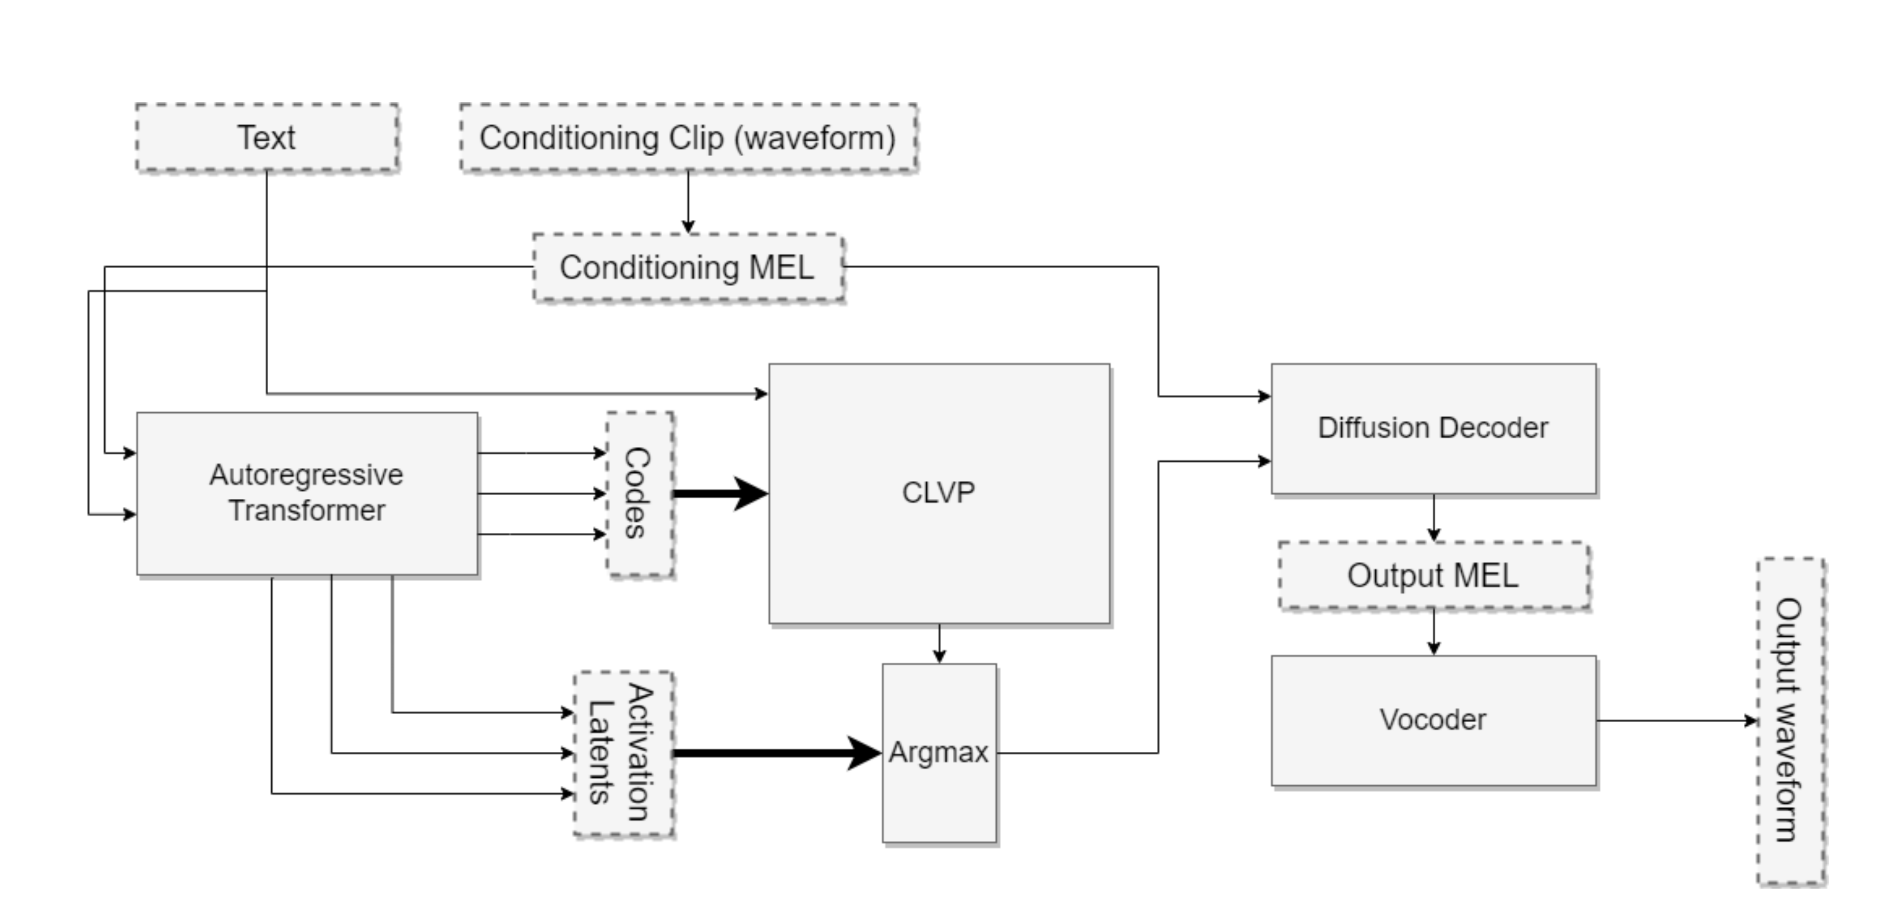


## 1. VQ-VAE


paper: [Neural Discrete Representation Learning](https://arxiv.org/pdf/1711.00937)

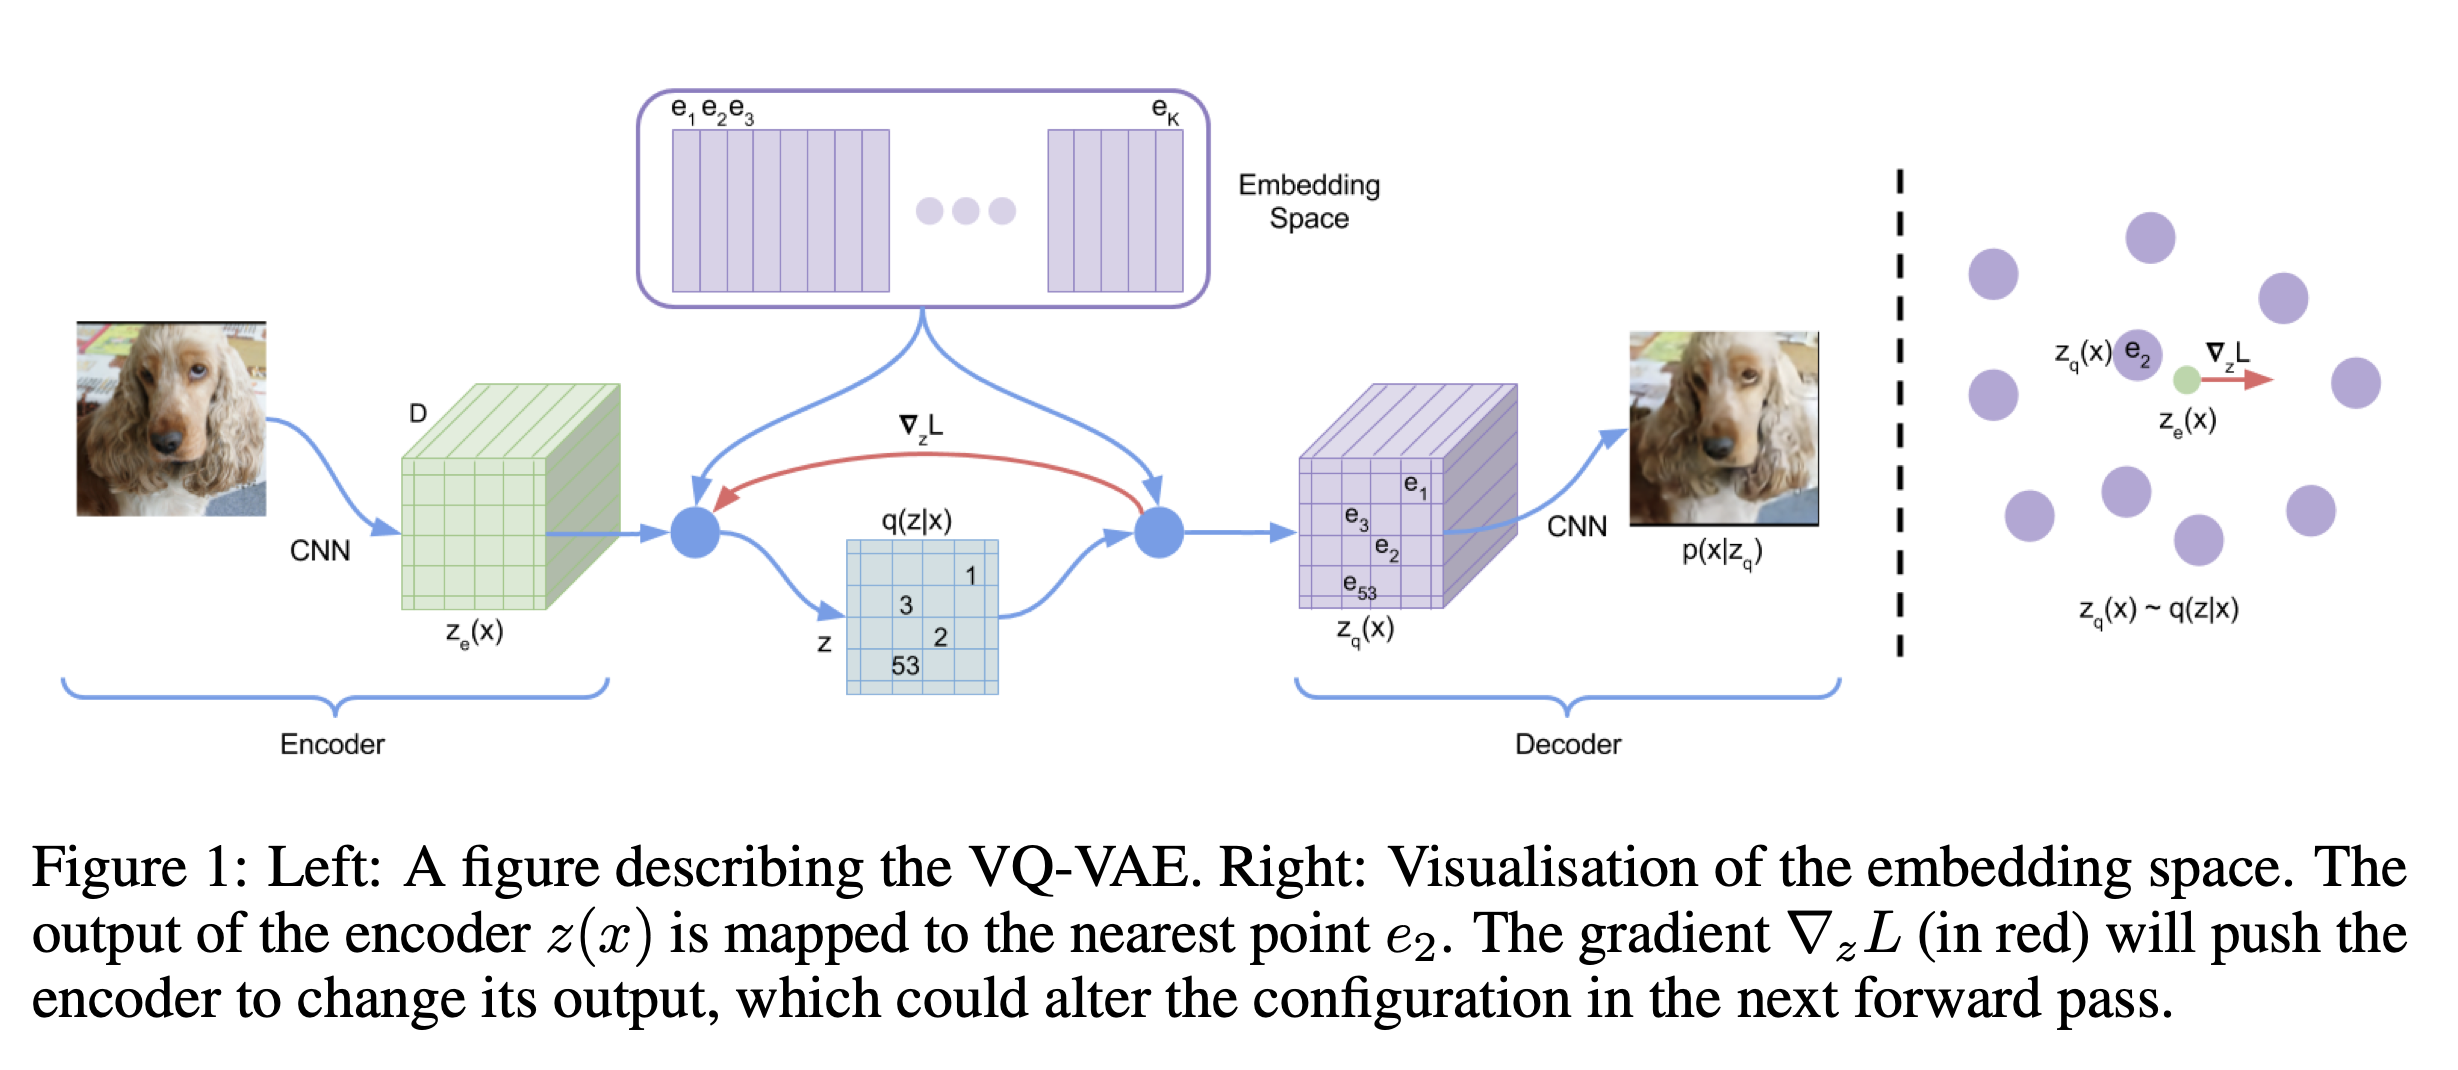

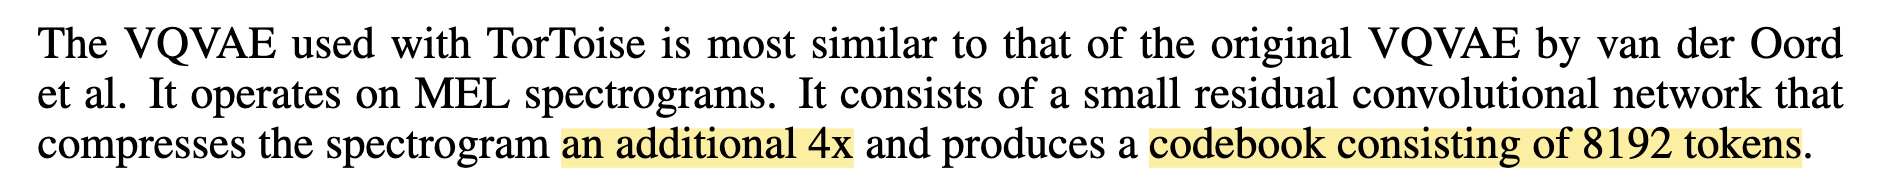


## Autoregressive Transformer


BPE 

check whisper lection

* causal attention
* transformer blocks
* shift loss

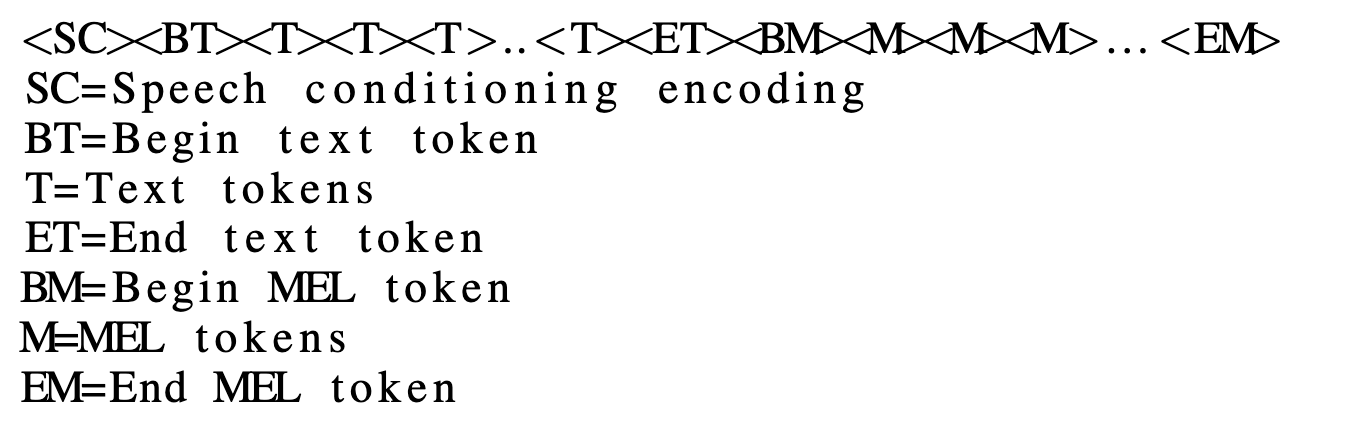

## Speaker conditioning

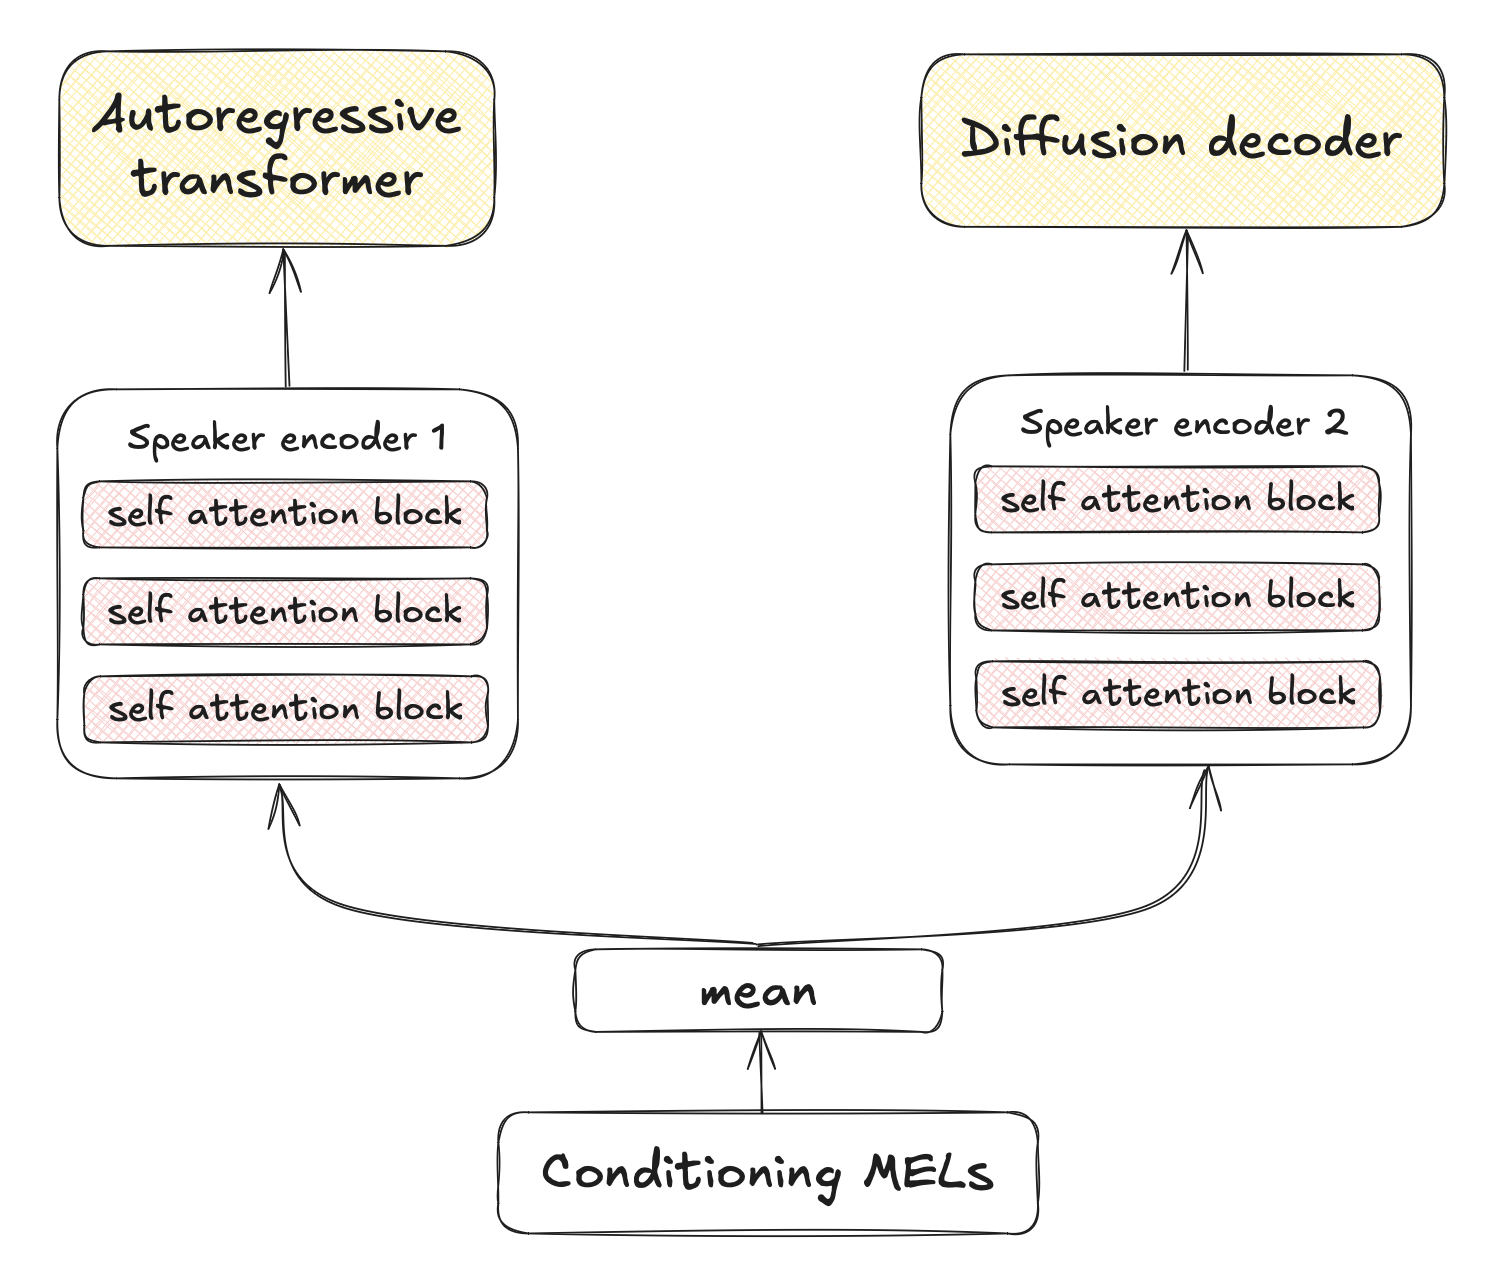

## Diffusion decoder

* DDIM
* latent input fine-tuning
* 

## CLVP

Contrastive Language-Voice Pretrained Transformer, inspired by CLIP

paper: [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/pdf/2103.00020)

* pretraining on matching pairs
* symmetric cross-entropy loss

Given a batch of N (image, text) pairs, CLIP is trained to predict which of the N × N possible (image, text) pairings across a batch actually occurred. To do this, CLIP learns a multi-modal embedding space by jointly training an image encoder and text encoder to maximize the cosine similar- ity of the image and text embeddings of the N real pairs in the batch while minimizing the cosine similarity of the embeddings of the N2 − N incorrect pairings.

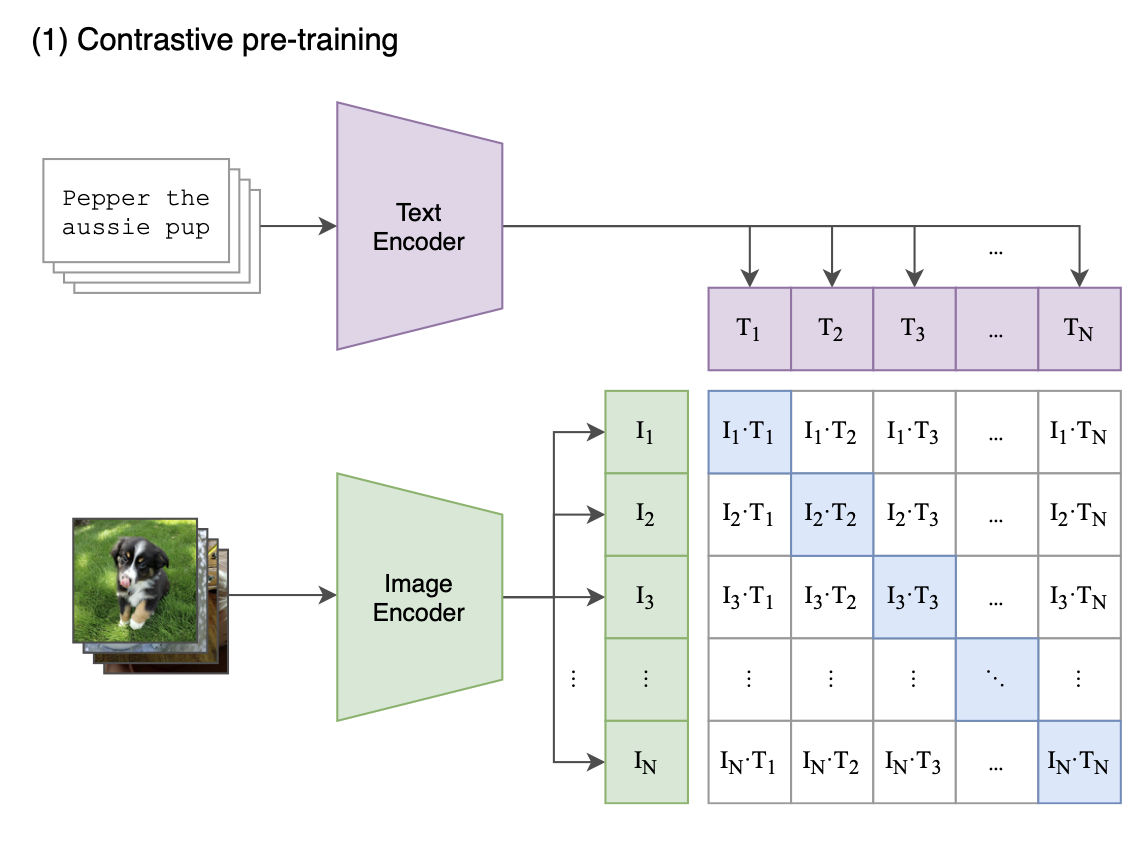

# Overview of TTS systems

## VALL-E (2023)

paper: [Neural Codec Language Models are Zero-Shot Text to Speech Synthesizers](https://arxiv.org/pdf/2301.02111)

* codec with RVQ
* AR transformer for the first RVQ layer
* non-AR transformer for all other layers
* speaker conditioning without separate encoder

### Encodec

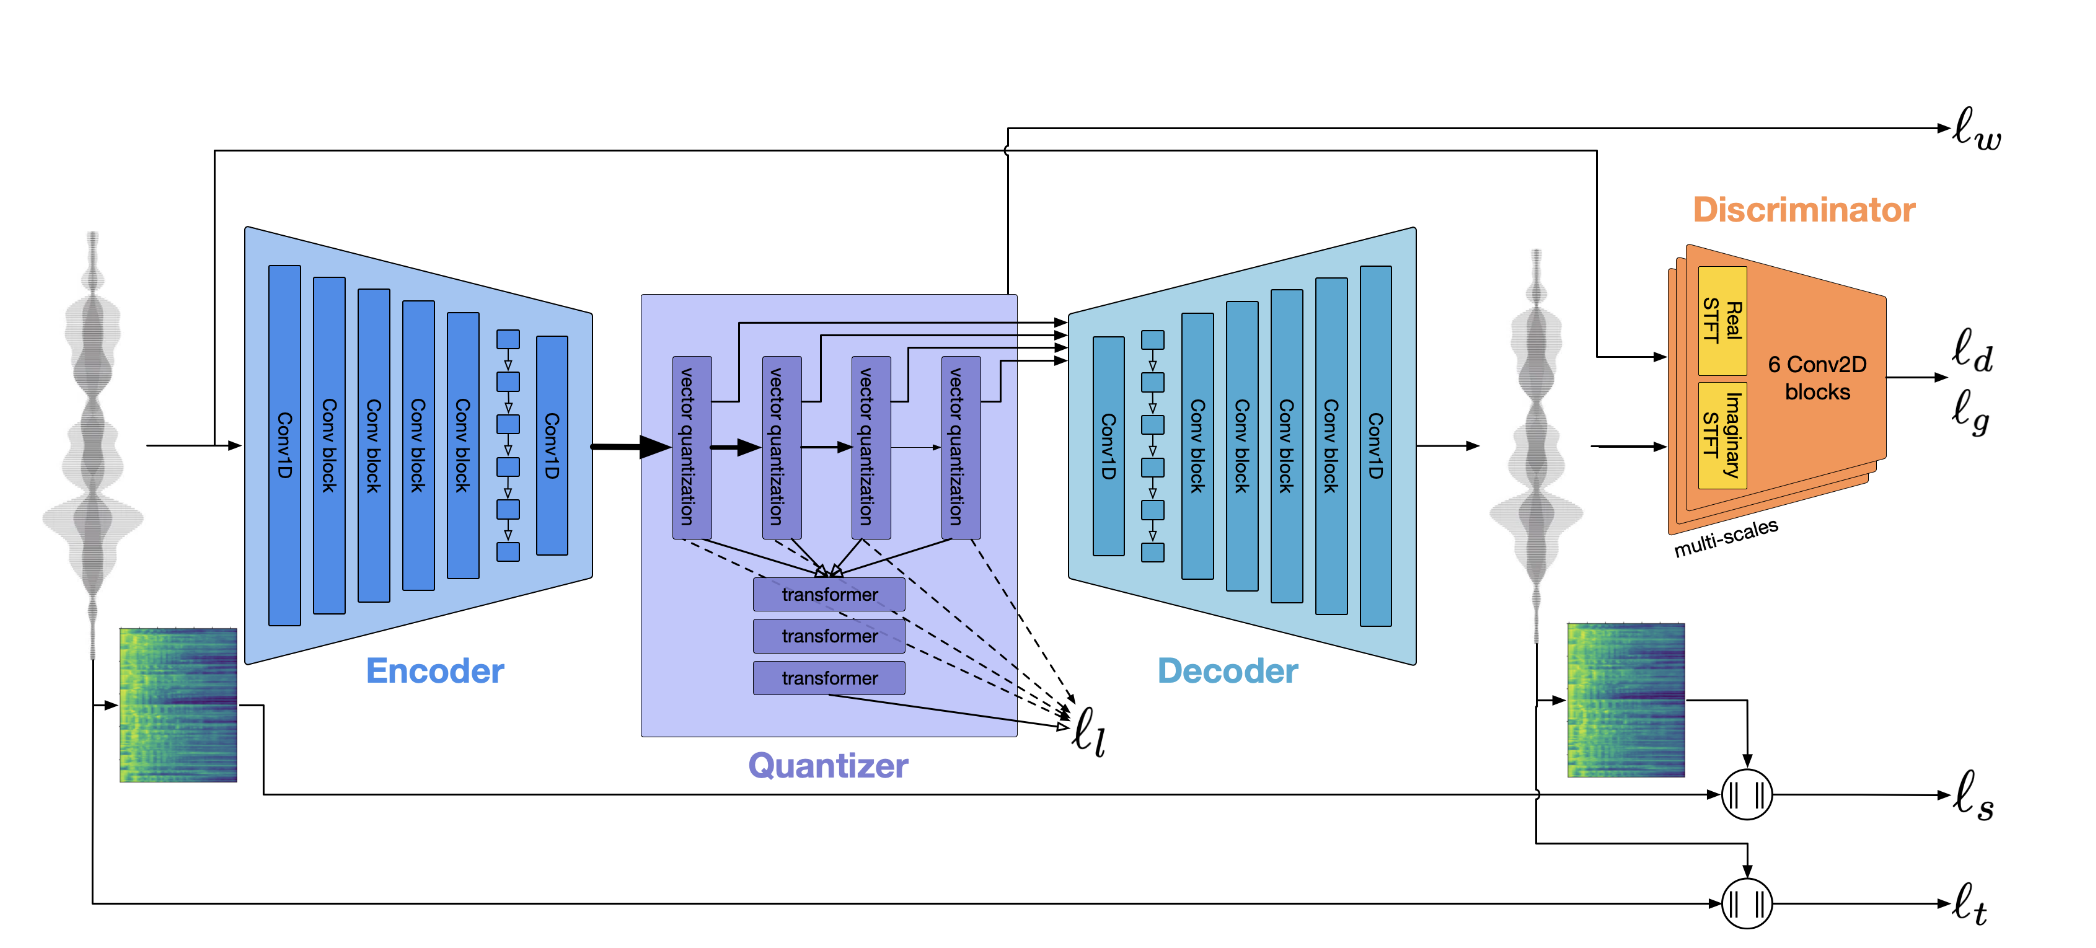

### VALL-E

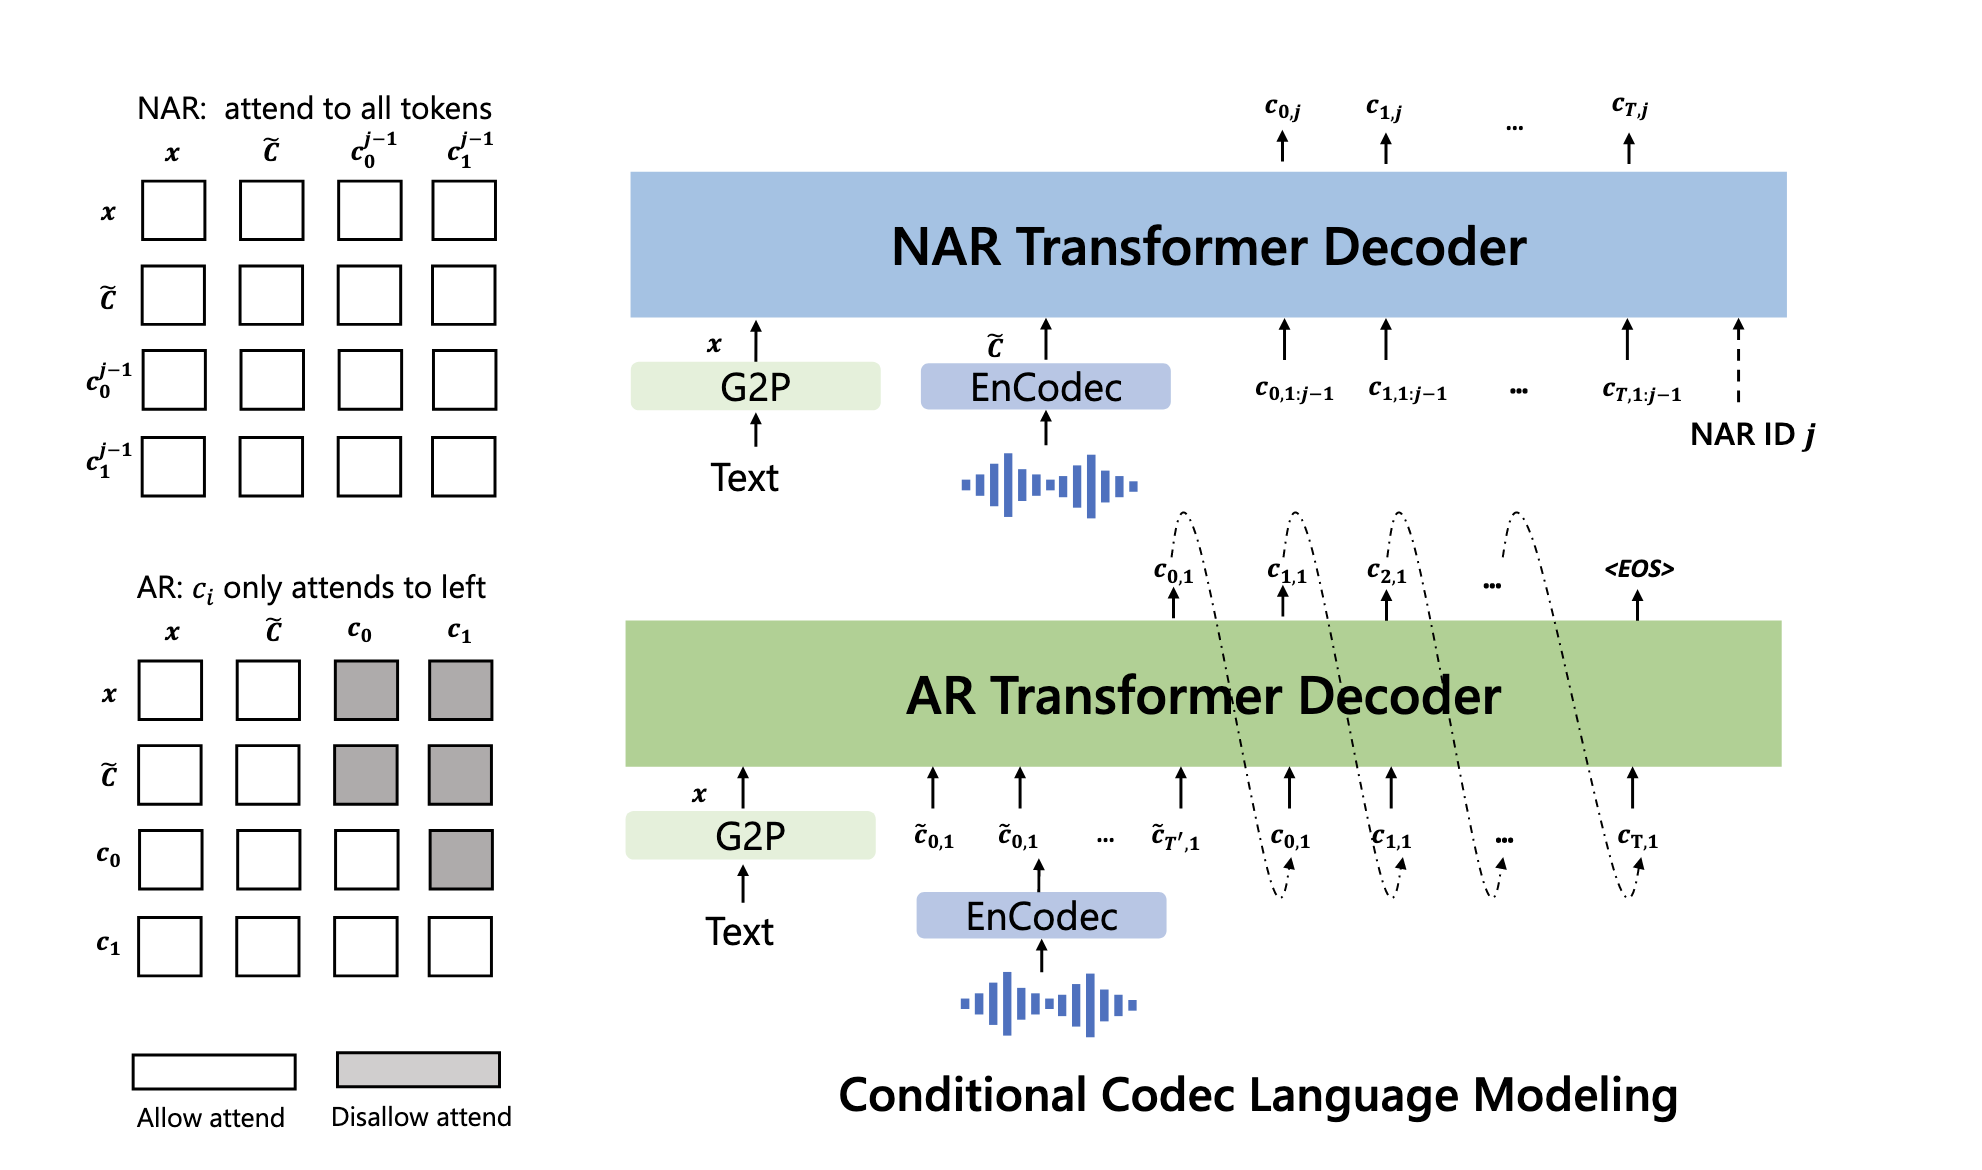

## xTTS v2 (2024)

paper: [XTTS: a Massively Multilingual Zero-Shot Text-to-Speech Model](https://arxiv.org/pdf/2406.04904) 

* pretrained speaker encoder
* cnn decoder

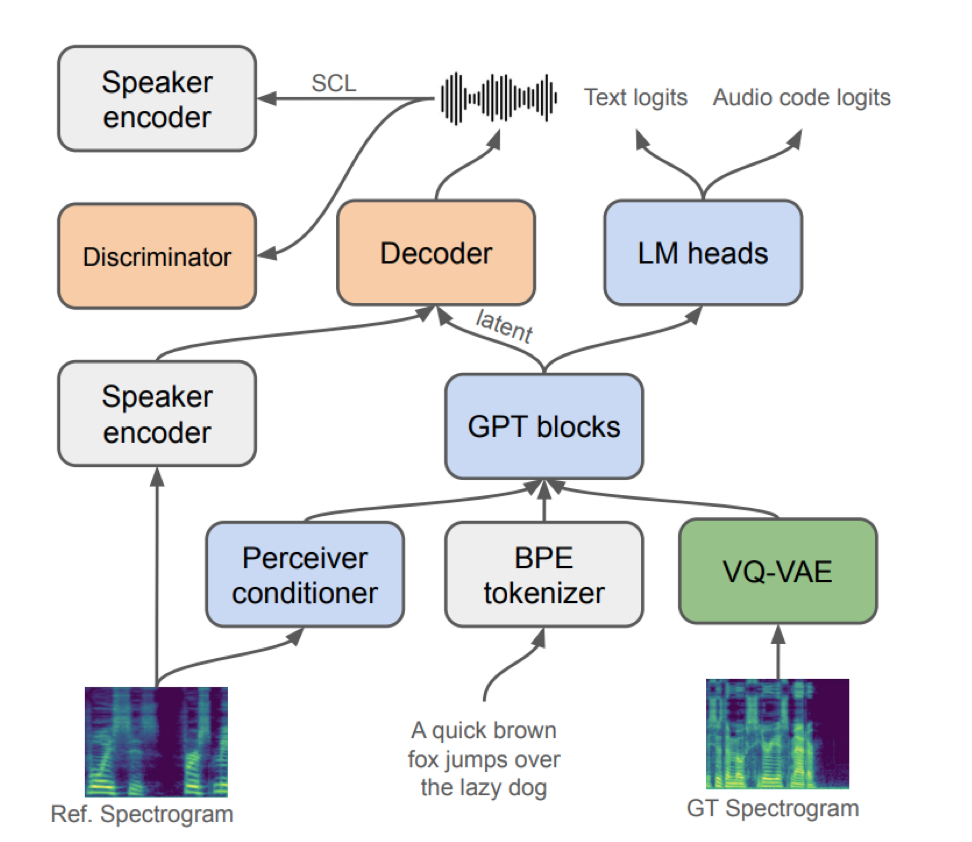

## CosyVoice 2 (2024)

paper: [CosyVoice 2: Scalable Streaming Speech Synthesis with Large Language Models](https://arxiv.org/pdf/2412.10117)

* Finite scalar quantization (FSQ) for VQ-VAE
* 


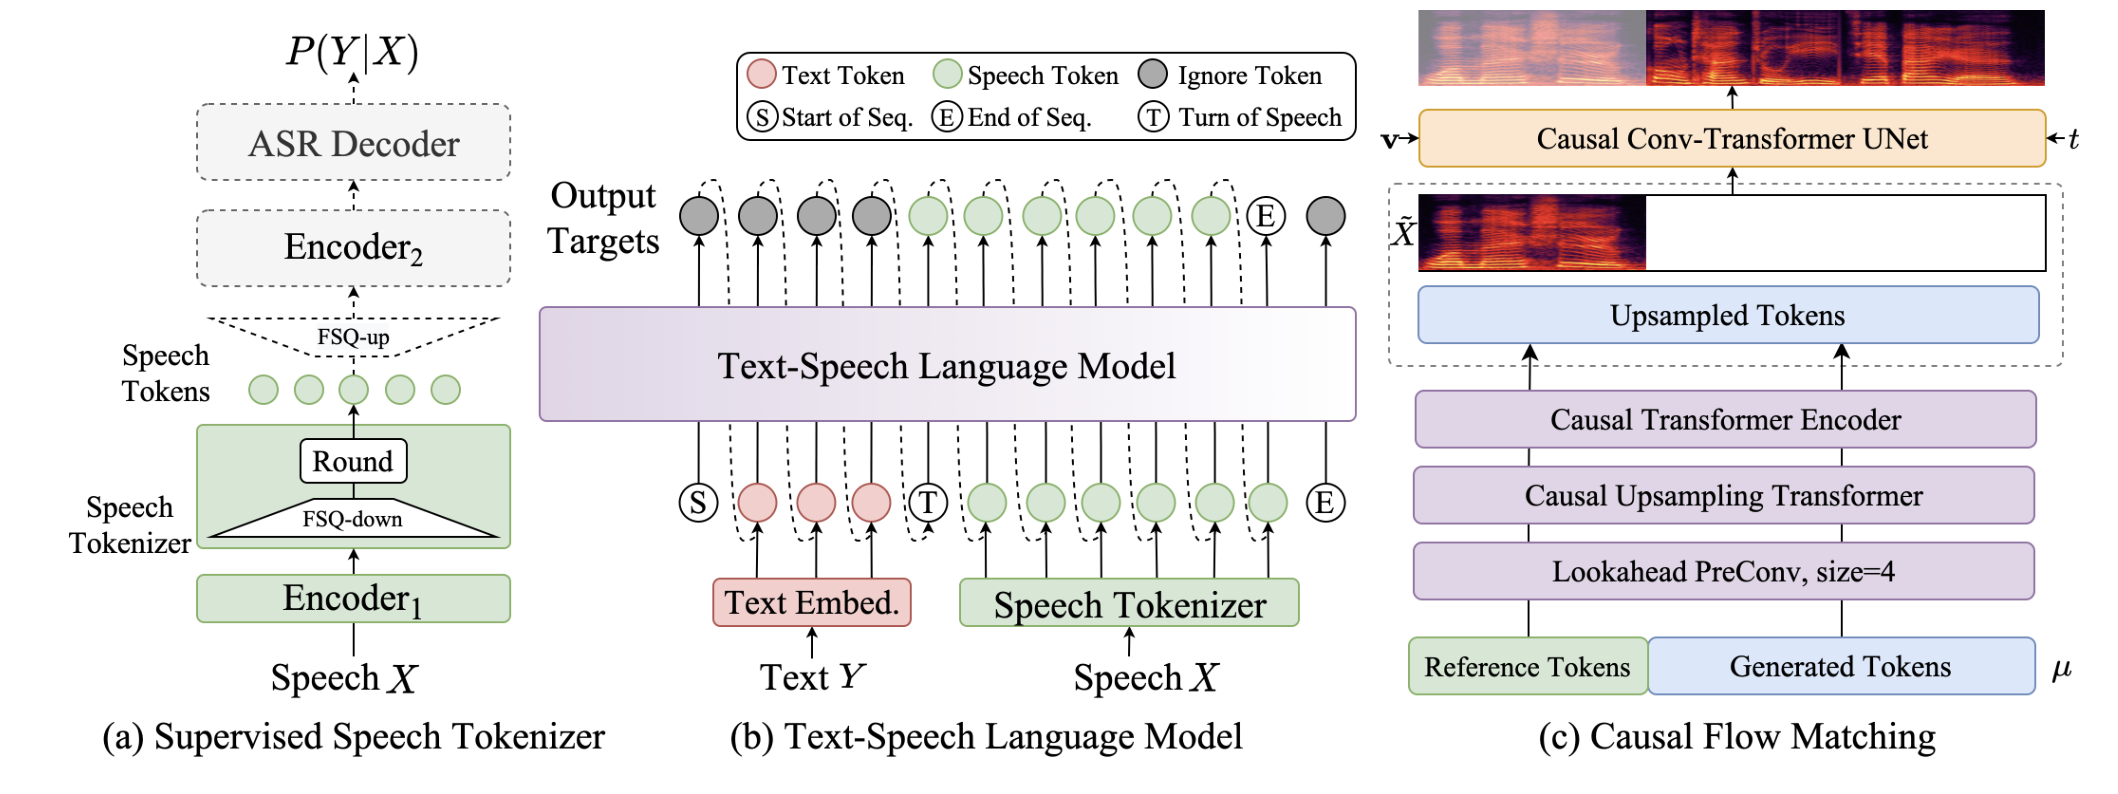

## Parler TTS (2024)

paper: [Natural language guidance of high-fidelity text-to-speech with synthetic annotations](https://arxiv.org/pdf/2402.01912)

* AR for all RVQ layers with delayed pattern
* Speaker conditioning via cross-attention

In [3]:
from IPython import display
display.Audio(audio_values[0].detach().cpu().numpy(), rate=processor.sampling_rate)

NameError: name 'audio_values' is not defined

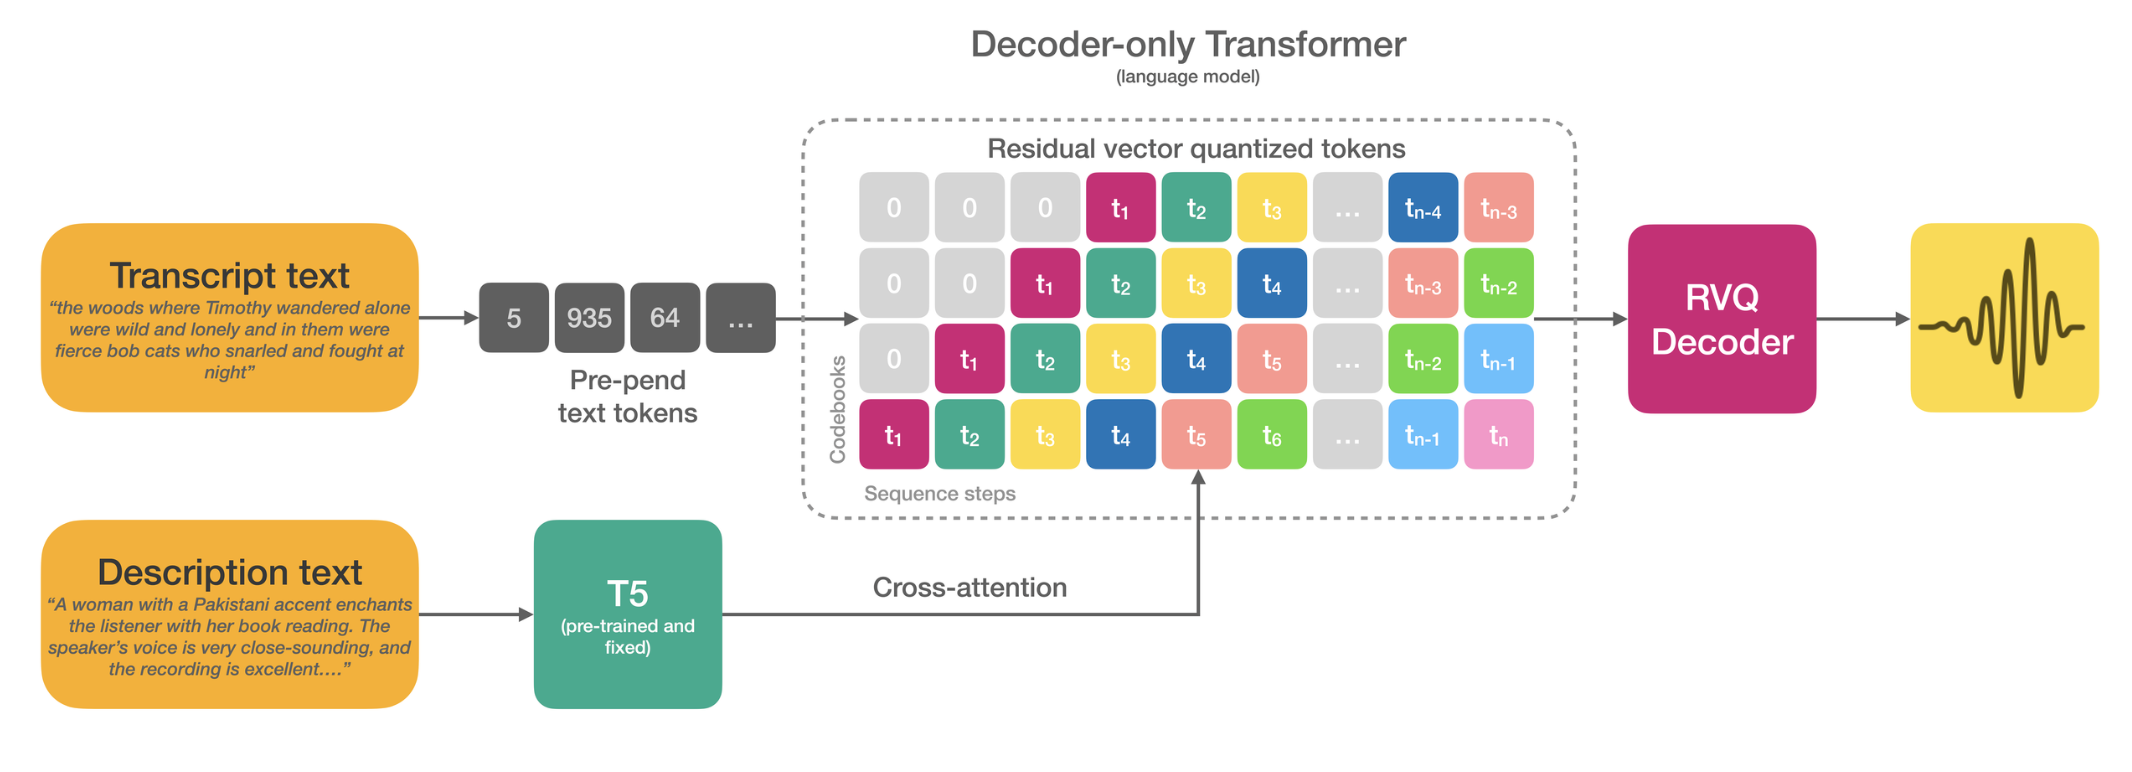

# Training LLM TTS 

* Flattened encodec with 2 quantizers 
* bpe tokenizer 
* gpt2
* native decoder

## 1. Dataset

LJspeech: https://www.kaggle.com/datasets/mathurinache/the-lj-speech-dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import torchaudio
import os

root_dir = "./data" 
os.makedirs(root_dir, exist_ok=True)

ljspeech_dataset = torchaudio.datasets.LJSPEECH(root=root_dir, download=True)

waveform, sample_rate, transcript, normalized_transcript = ljspeech_dataset[0]

print("Waveform shape:", waveform.shape)
print("Sample rate:", sample_rate)
print("Transcript:", transcript)

Waveform shape: torch.Size([1, 212893])
Sample rate: 22050
Transcript: Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition


In [3]:
from IPython import display

display.Audio(waveform, rate=sample_rate)

In [4]:
import pandas as pd
import numpy as np

meta = pd.read_csv(f'{root_dir}/LJSpeech-1.1/metadata.csv', sep='|', header=None,
                   names=['id', 'text', 'text_norm'])
meta['text_norm'] = meta['text_norm'].fillna(meta['text'])
meta['filepath'] = meta['id'].apply(lambda s: f'{root_dir}/LJSpeech-1.1/wavs/{s}.wav')

rng = np.random.default_rng(42)
perm = rng.permutation(len(meta))
split_at = int(0.9 * len(meta))
train_df = meta.iloc[perm[:split_at]].reset_index(drop=True)
val_df   = meta.iloc[perm[split_at:]].reset_index(drop=True)
print(f'train: {len(train_df)}  val: {len(val_df)}')
train_df.head(2)

train: 11790  val: 1310


,id,text,text_norm,filepath
0,LJ022-0092,and such projects as they approve will be next...,and such projects as they approve will be next...,./data/LJSpeech-1.1/wavs/LJ022-0092.wav
1,LJ039-0028,"was shipped from Los Angeles on March 20, 1963...","was shipped from Los Angeles on March twenty, ...",./data/LJSpeech-1.1/wavs/LJ039-0028.wav


## 2. Audio codec

In [4]:
pip install git+https://github.com/lucadellalib/focalcodec

  Cloning https://github.com/lucadellalib/focalcodec to /tmp/pip-req-build-csijncvu
  Running command git clone --filter=blob:none --quiet https://github.com/lucadellalib/focalcodec /tmp/pip-req-build-csijncvu
  Resolved https://github.com/lucadellalib/focalcodec to commit 912b7f2c0cd43d54a8aed296bbcc925dec7d4ea3
  Preparing metadata (setup.py) ... done
  Created wheel for focalcodec: filename=focalcodec-0.0.2-py3-none-any.whl size=49223 sha256=64cc1f6ce2072e446d68d06a1e72aca8fb0d0836b3bf4b1d4a1c01716080df2d
  Stored in directory: /tmp/pip-ephem-wheel-cache-ti2dzy9m/wheels/06/df/ee/ed75f5243d5b04c56febca9b19ccc875c27bf1075f97748a2b
Successfully built focalcodec
Note: you may need to restart the kernel to use updated packages.


In [5]:
from focalcodec import FocalCodec
import torch
import librosa
import matplotlib.pyplot as plt
import soundfile as sf
import torchaudio


device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
codec = FocalCodec.from_pretrained('lucadellalib/focalcodec_25hz').to(device).eval()
for p in codec.parameters(): p.requires_grad_(False)
CODEBOOK_SIZE = int(codec.codebook.shape[0])
CODEC_SR = codec.sample_rate_input
print(f'codebook={CODEBOOK_SIZE}, sr_in/out={CODEC_SR}/{codec.sample_rate_output}')


codebook=8192, sr_in/out=16000/16000


In [ ]:

def load_wav_16k(path):
    arr, sr = sf.read(path, dtype='float32', always_2d=False)
    if arr.ndim > 1: arr = arr.mean(-1)
    wav = torch.from_numpy(arr)
    if sr != CODEC_SR: wav = torchaudio.functional.resample(wav, sr, CODEC_SR)
    return wav  # (T,)

def plot_mel(wav, sr, title=''):
    wav = np.asarray(wav).astype(np.float32)
    if wav.ndim > 1: wav = wav.mean(0)
    S = librosa.feature.melspectrogram(y=wav, sr=sr, n_fft=1024, hop_length=256,
                                       n_mels=80, fmin=50, fmax=sr//2)
    fig, ax = plt.subplots(figsize=(max(6, len(wav)/sr*1.2), 3))
    librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=sr, hop_length=256,
                              x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(title, fontsize=9); plt.show()

row = val_df.iloc[0]
wav = load_wav_16k(row['filepath']).to(device)
with torch.no_grad():
    toks = codec.sig_to_toks(wav.unsqueeze(0))
    rec = codec.toks_to_sig(toks).squeeze(0).detach().cpu().numpy()
print(f'{row["id"]}: {wav.shape[-1]/CODEC_SR:.2f}s -> {toks.shape[-1]} tokens')
plot_mel(wav.cpu().numpy(), CODEC_SR, f'original: {row["id"]}')
plot_mel(rec, codec.sample_rate_output, f'codec round-trip: {row["id"]}')

# 3. Precompute features

In [7]:
from tqdm.auto import tqdm
from transformers import GPT2TokenizerFast

In [8]:
tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')


In [ ]:

CACHE_DIR = os.path.join(root_dir, 'tokenized')
os.makedirs(CACHE_DIR, exist_ok=True)
TRAIN_CACHE = os.path.join(CACHE_DIR, 'train.pt')
VAL_CACHE   = os.path.join(CACHE_DIR, 'val.pt')


@torch.no_grad()
def encode_split(df, cache_path, batch_size=16, overwrite=False, limit: int = 32):
    if os.path.exists(cache_path) and not overwrite:
        print(f'load cache: {cache_path}')
        return torch.load(cache_path, weights_only=False)

    # comment out to precompute on full dataset
    df = df.iloc[:limit]

    recs = df.to_dict('records')
    paths = [r['filepath'] for r in recs]
    order = np.argsort([os.path.getsize(p) for p in paths])
    out = [None] * len(recs)
    for start in tqdm(range(0, len(recs), batch_size)):
        idxs = order[start:start+batch_size]
        wavs = [load_wav_16k(paths[i]) for i in idxs]
        lens = torch.tensor([w.numel() for w in wavs], dtype=torch.float32)
        L = int(lens.max()); batch = torch.zeros(len(wavs), L)
        for j, w in enumerate(wavs): batch[j, :w.numel()] = w
        batch = batch.to(device)
        toks = codec.sig_to_toks(batch, length=(lens/L).to(device))
        tok_lens = ((lens/L).to(device) * toks.shape[-1]).round().clamp(max=toks.shape[-1]).to(torch.long)
        for j, i in enumerate(idxs):
            text_ids = tokenizer.encode(recs[i]['text_norm'], add_special_tokens=False)
            text_ids = torch.tensor(text_ids, dtype=torch.long)
            audio_ids = toks[j, :tok_lens[j]].to(torch.long).cpu()
            out[i] = {
                'id': recs[i]['id'],
                'text': recs[i]['text_norm'],
                'text_ids': text_ids,
                'audio_ids': audio_ids,
                'n_text': int(text_ids.numel()),
                'n_audio': int(audio_ids.numel()),
            }

    torch.save(out, cache_path)
    print(f'saved {len(out)} items to {cache_path}')
    return out


print('tokenize train'); train_items = encode_split(train_df, TRAIN_CACHE, limit=3000, overwrite=True)
print('tokenize val');   val_items   = encode_split(val_df,   VAL_CACHE, limit=700, overwrite=True)
a = np.array([r['n_audio'] for r in train_items])
t = np.array([r['n_text']  for r in train_items])
print(f'audio tokens: mean={a.mean():.1f} p95={np.percentile(a,95):.0f} max={a.max()}')
print(f'text  tokens: mean={t.mean():.1f} p95={np.percentile(t,95):.0f} max={t.max()}')

In [9]:
from torch.utils.data import Dataset


class TokenizedLJSpeech(Dataset):
    def __init__(self, cache_path, max_total_len=1024):
        items = torch.load(cache_path, weights_only=False)
        self.items = [it for it in items if it["n_text"] + it["n_audio"] + 2 <= max_total_len]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        it = self.items[i]
        return {
            "id": it["id"],
            "text_ids": it["text_ids"].long(),
            "audio_ids": it["audio_ids"].long(),
        }


def collate(batch):
    B = len(batch)
    text_lens = torch.tensor([b["text_ids"].numel() for b in batch], dtype=torch.long)
    audio_lens = torch.tensor([b["audio_ids"].numel() for b in batch], dtype=torch.long)
    text_ids = torch.zeros(B, int(text_lens.max()), dtype=torch.long)
    audio_ids = torch.zeros(B, int(audio_lens.max()), dtype=torch.long)
    for i, b in enumerate(batch):
        text_ids[i, : b["text_ids"].numel()] = b["text_ids"]
        audio_ids[i, : b["audio_ids"].numel()] = b["audio_ids"]
    return {"text_ids": text_ids, "text_lens": text_lens,
            "audio_ids": audio_ids, "audio_lens": audio_lens}

# 4. TTS class

In [9]:
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2LMHeadModel
from datetime import datetime
from tqdm import tqdm



EPSILON = 1e-5



@dataclass
class GPT2TTSConfig:
    base_model: str = "gpt2"
    codebook_size: int = CODEBOOK_SIZE
    n_special_tokens: int = 2  # BOS, EOS

    @property
    def audio_vocab_size(self) -> int:
        return self.codebook_size + self.n_special_tokens

    @property
    def bos_id(self) -> int:
        return self.codebook_size

    @property
    def eos_id(self) -> int:
        return self.codebook_size + 1


class GPT2TTS(nn.Module):
    def __init__(self, cfg: GPT2TTSConfig):
        super().__init__()
        self.cfg = cfg
        self.base = GPT2LMHeadModel.from_pretrained(cfg.base_model)
        H = self.base.config.n_embd
        V = cfg.audio_vocab_size
        
        self.audio_emb = nn.Embedding(V, H)
        self.audio_head = nn.Linear(H, V, bias=False)
        nn.init.normal_(self.audio_emb.weight, std=0.02)
        nn.init.normal_(self.audio_head.weight, std=0.02)

    def _build_inputs(self, text_ids, text_lens, audio_ids, audio_lens, verbose: bool = False):
        """Pack a variable-length batch into a single (B, L, H) tensor with mask + labels.

        Inputs
        ------
        text_ids   : LongTensor[B, T_text_max]   padded GPT-2 BPE ids
        text_lens  : LongTensor[B]               actual text length per row
        audio_ids  : LongTensor[B, T_audio_max]  padded FocalCodec ids (all < codebook_size)
        audio_lens : LongTensor[B]               actual audio length per row

        Per-row layout (let tl = text_lens[i], al = audio_lens[i]):

            position :  0 .. tl-1   tl     tl+1 .. tl+al    tl+1+al    tl+2+al .. L-1
            content  :   text       BOS         audio          EOS          PAD

        Returns
        -------
        inputs : FloatTensor[B, L, H]
            Embeddings. Text goes through GPT-2's wte; audio/BOS/EOS through self.audio_emb.
        mask   : LongTensor[B, L]
            1 on real tokens, 0 on PAD. This is the `attention_mask` for GPT-2.
        labels : LongTensor[B, L]
            Target audio ids at positions that SHOULD be predicted (audio + EOS),
            and -100 everywhere else (text, BOS, PAD).
            Do NOT apply the causal shift here — `forward` does that.
        """

        # Gotchas
        # - L must be the padded max across the batch: max_i(tl + al + 2).
        # - Padded positions must be 0 in `mask` AND -100 in `labels` (or pass another "ignore" value to loss function)
        # - The BOS position is NOT a label (we don't train to predict BOS from text).
        # - The EOS position IS a label (we want the model to learn when to stop).
        # - text_emb and audio_emb have the same hidden size H — concatenate on time.

        start_dt = datetime.now()
        if verbose:
            print(f"Building inputs since {start_dt}")
            
        inputs, mask, labels = None, None, None
        # ↓↓↓ your code here ↓↓↓
        device = next(self.parameters()).device
        text_ids = text_ids.to(device).long()
        text_lens = text_lens.to(device).long()
        audio_ids = audio_ids.to(device).long()
        audio_lens = audio_lens.to(device).long()

        B = text_ids.size(0)
        H = self.base.config.n_embd

        # lengths == text + BOS + audio + EOS
        lengths = text_lens + audio_lens + 2
        L = int(lengths.max().item())

        inputs = torch.zeros(B, L, H, device=device, dtype=self.base.transformer.wte.weight.dtype)
        mask = torch.zeros(B, L, device=device, dtype=torch.long)
        labels = torch.full((B, L), -100, device=device, dtype=torch.long)

        for i in range(B):
            tl = int(text_lens[i].item())
            al = int(audio_lens[i].item())
            end = tl + al + 2  #  + BOS and EOS

            if tl > 0:
                    inputs[i, :tl] = self.base.transformer.wte(text_ids[i, :tl])

            audio_seq = torch.empty(al + 2, device=device, dtype=torch.long)
            audio_seq[0] = self.cfg.bos_id
            audio_seq[1:1 + al] = audio_ids[i, :al]
            audio_seq[1 + al] = self.cfg.eos_id
            inputs[i, tl:end] = self.audio_emb(audio_seq)

            mask[i, :end] = 1
            
            labels[i, tl+1: tl+1+al] = audio_ids[i, :al]  # audio tokens
            labels[i, tl+1+al] = self.cfg.eos_id  # EOS

        if verbose:        
            print(f"Imports built in {datetime.now() - start_dt}")
        # ↑↑↑ your code here ↑↑↑

        return inputs, mask, labels

    def forward(self, text_ids, text_lens, audio_ids, audio_lens):
        inputs, mask, labels = self._build_inputs(text_ids, text_lens, audio_ids, audio_lens)
        h = self.base.transformer(
            inputs_embeds=inputs, attention_mask=mask, return_dict=True
        ).last_hidden_state
        logits = self.audio_head(h)  # (B, L, V)

        # Compute the causal-LM cross-entropy loss.
        # In a causal LM the hidden state at position t predicts the token at position t+1.
        # Use ignore_index=-100 so masked positions don't contribute. Cast logits to float32
        # before the softmax for numerical stability under bf16/fp16.
        # Expected: a scalar tensor `loss`.

        loss = None
        # ↓↓↓ your code here ↓↓↓
        shift_logits = logits[:, :-1, :].contiguous().float()
        shift_labels = labels[:, 1:].contiguous()
        
        loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            ignore_index=-100,
        )
        
        valid_tokens = (shift_labels != -100).sum()
        # ↑↑↑ your code here ↑↑↑

        return {"loss": loss, "logits": logits, "valid_tokens": valid_tokens}  

    @torch.no_grad()
    def generate_audio(
        self,
        text_ids,
        max_new_tokens=400,
        do_sample: bool = False,
        temperature=0.9,
        top_k=50,
        top_p=1.0,
        verbose: bool = False,
    ):
        """Autoregressively sample audio tokens conditioned on text.

        Runs [text][BOS] through the transformer once to prime the KV cache,
        leaving `h` as the hidden state after BOS. You write the sampling loop.
        """
        start_dt = datetime.now()
        if verbose:
            print(f"Generating audio since {start_dt}...")

        self.eval()
        device = text_ids.device
        text_ids = text_ids.view(-1).long().to(device)
        text_emb = self.base.transformer.wte(text_ids).unsqueeze(0)  # (1, T, H)
        bos = self.audio_emb.weight[self.cfg.bos_id].view(1, 1, -1)  # (1, 1, H)
        prefix = torch.cat([text_emb, bos], dim=1)  # (1, T+1, H)
        mask = torch.ones(1, prefix.size(1), device=device, dtype=torch.long)

        out = self.base.transformer(
            inputs_embeds=prefix,
            attention_mask=mask,
            use_cache=True,
            return_dict=True,
        )
        past = out.past_key_values
        h = out.last_hidden_state[:, -1, :]  # (1, H) — hidden state after BOS

        # Autoregressive sampling loop. Starting from `h` (hidden state after BOS), repeatedly:
        # project to audio-vocab logits, apply temperature + top-k/top-p, sample a token, handle
        # stopping, and feed the token back through
        # the transformer using `past` to refresh `h`. Stop at EOS or max_new_tokens.
        # Return the collected audio ids as a LongTensor on `device`.

        generated = []
        # ↓↓↓ your code here ↓↓↓
        temperature = max(float(temperature), EPSILON)

        for _ in range(max_new_tokens):
            logits = self.audio_head(h).float().squeeze(0) / temperature

            if do_sample:
                # Top-K Sampling
                if all([top_k is not None, top_k > 0, top_k < logits.numel()]):
                    kth = torch.topk(logits, k=top_k).values[-1]
                    logits = logits.masked_fill(logits < kth, float("-inf"))

                # Top-P (Nucleus) Sampling
                if top_p is not None and top_p < 1.0:
                    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
                    cumulative_probs = torch.cumsum(
                        F.softmax(sorted_logits, dim=-1), dim=-1
                    )

                    # Remove tokens with cumulative probability above the threshold
                    sorted_indices_to_remove = cumulative_probs > top_p

                    # Shift the removed indices to the right to keep the first token above the threshold
                    # This ensures we always keep at least 1 token mass
                    sorted_indices_to_remove[1:] = sorted_indices_to_remove[:-1].clone()
                    sorted_indices_to_remove[0] = False

                    # Mask out the identified tokens
                    logits[sorted_indices[sorted_indices_to_remove]] = float("-inf")

                probs = F.softmax(logits, dim=-1)
                token = torch.multinomial(probs, num_samples=1)
            else:
                # Greedy decoding if do_sample is False
                token = torch.argmax(logits, dim=-1, keepdim=True)

            token_id = int(token.item())

            if token_id == self.cfg.eos_id:
                break

            if token_id < self.cfg.codebook_size:  # Protection from BOS
                generated.append(token_id)

            token_emb = self.audio_emb(token.view(1, 1))
            mask = torch.cat(
                [mask, torch.ones(1, 1, device=device, dtype=torch.long)], dim=1
            )
            out = self.base.transformer(
                inputs_embeds=token_emb,
                attention_mask=mask,
                past_key_values=past,
                use_cache=True,
                return_dict=True,
            )
            past = out.past_key_values
            h = out.last_hidden_state[:, -1, :]

        if verbose:
            print(f"Audio generated in {datetime.now() - start_dt}")
        # ↑↑↑ your code here ↑↑↑

        return torch.tensor(generated, dtype=torch.long, device=device)

In [11]:
from torch.utils.data import DataLoader

train_ds = TokenizedLJSpeech(TRAIN_CACHE)
print(train_ds[0])


train_dl = DataLoader(train_ds, collate_fn=collate, batch_size=4, num_workers=4, persistent_workers=True, shuffle=True, pin_memory=True)
for k, v in next(iter(train_dl)).items():
    print(k, v.shape)

{'id': 'LJ022-0092', 'text_ids': tensor([  392,   884,  4493,   355,   484, 14762,   481,   307,  1306,  8948,
          284,   262,  1992,   508,   739,   262,  2191,   318,  2672,   284,
          787,  2457, 49157,    13]), 'audio_ids': tensor([7880,  550, 1578, 1642, 5738, 5798, 3304, 7329, 1317, 7123, 7672, 8109,
        2658, 3266, 5956, 5611, 7615, 1910, 5057, 2306, 4609, 7814, 5775, 5134,
        2547, 6843, 1571, 1907, 1892, 1621, 3069, 7165, 4788, 5948, 5310,  131,
        1508, 1464, 5698, 7267, 4324, 2619, 6740, 5445, 7059, 5599, 4102, 4127,
        7836, 7836, 7190, 4630, 6226, 2250, 6535, 4503, 3414, 5976, 1794, 6932,
        1782, 3833, 5733, 1735, 2380, 7709, 2701, 6346,  448, 4700, 4348, 3310,
        6313, 5281, 4962, 7203, 6005, 6946, 7624, 5565, 1777, 6109, 8104, 4263,
        5167, 4445, 5121, 5264, 4711, 4590, 7095, 6768, 6335,  303, 1397, 4595,
        6776, 1008, 1127, 1127, 3019, 1975, 4659, 4850, 4819, 7366,  163, 6685,
        5184, 8095, 5130, 5706, 6830, 45

In [10]:
cfg = GPT2TTSConfig()
tts = GPT2TTS(cfg).to(device)

# Training gptTTS on LJ Speech

### Auxiliary instances

In [13]:
import typing as ty


def clear_caches(func: ty.Callable):
    def wrapper(*args, **kwargs):
        result = func(*args, **kwargs)
        gc.collect()
        torch.cuda.empty_cache()
        return result
    return wrapper


def move_batch_to_device(batch, device):
    return {
        k: v.to(device) if torch.is_tensor(v) else v
        for k, v in batch.items()
    }


class CUDAPrefetcher:
    def __init__(self, loader, device):
        self.loader = iter(loader)
        self.device = device
        self.stream = torch.cuda.Stream()
        self.next_batch = None
        self.preload()

    def _move_to_device(self, batch):
        return {
            k: v.to(self.device, non_blocking=True) if torch.is_tensor(v) else v
            for k, v in batch.items()
        }

    def preload(self):
        try:
            batch = next(self.loader)
        except StopIteration:
            self.next_batch = None
            return

        with torch.cuda.stream(self.stream):
            self.next_batch = self._move_to_device(batch)

    def next(self):
        torch.cuda.current_stream().wait_stream(self.stream)

        batch = self.next_batch

        if batch is not None:
            for v in batch.values():
                if torch.is_tensor(v):
                    v.record_stream(torch.cuda.current_stream())

        self.preload()
        return batch


## Training and validation functions

In [14]:
from torch import nn
from torch.optim import Optimizer


def train_epoch_tts(
    model: nn.Module,
    dl: DataLoader,
    opt: Optimizer,
    device: torch.device = device,
    grad_clip: float | None = 1.,
):
    model.train()
    current_loss = .0
    total_items = 0

    prefetcher = CUDAPrefetcher(dl, device)
    batch = prefetcher.next()

    pbar = tqdm(total=len(dl))

    while batch is not None:
        # batch = move_batch_to_device(batch, device)

        opt.zero_grad(set_to_none=True)

        out = model(
            text_ids=batch["text_ids"],
            text_lens=batch["text_lens"],
            audio_ids=batch["audio_ids"],
            audio_lens=batch["audio_lens"],
        )

        loss = out["loss"]
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        opt.step()

        # bs = batch["text_ids"].size(0)
        n_tokens = out["valid_tokens"].item()
        # current_loss += loss.item() * bs
        current_loss += loss.item() * n_tokens  # Audio samples may have varying lengths
        # total_items += bs
        total_items += n_tokens

        pbar.update(1)
        batch = prefetcher.next()
    pbar.close()
    
    epoch_loss = current_loss / max(1, total_items)
    return epoch_loss


@torch.no_grad()
def validate_tts(
    model: nn.Module,
    dl: DataLoader,
    device: torch.device = device,
):
    model.eval()
    current_loss = .0
    total_items = 0

    for batch in tqdm(dl):
        batch = move_batch_to_device(batch, device)

        out = model(
            text_ids=batch["text_ids"],
            text_lens=batch["text_lens"],
            audio_ids=batch["audio_ids"],
            audio_lens=batch["audio_lens"],
        )

        loss = out["loss"]

        # bs = batch["text_ids"].size(0)
        n_tokens = out["valid_tokens"].item()
        # current_loss += loss.item() * bs
        current_loss += loss.item() * n_tokens
        # total_items += bs
        total_items += n_tokens

    epoch_loss = current_loss / max(1, total_items)
    return epoch_loss

In [15]:
EPOCHS_CNT = 10
import gc


@clear_caches
def train_model_tts(
    model: nn.Module,
    train_dl: DataLoader,
    val_dl: DataLoader,
    opt: Optimizer,
    patience: int = 15,
    min_delta: float = 0.001,
    epochs_cnt: int = EPOCHS_CNT,
    device: torch.device = device,
    save_path: str | None = None,
):
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    patience_cnt = 0
    start_dt = datetime.now()

    if save_path is None:
        save_path = f"{model.__class__.__name__}_best.pth"

    for epoch in range(epochs_cnt):
        print(f"Epoch {epoch + 1}/{epochs_cnt}")

        train_loss = train_epoch_tts(
            model=model,
            dl=train_dl,
            opt=opt,
            device=device,
        )

        val_loss = validate_tts(
            model=model,
            dl=val_dl,
            device=device,
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Train loss: {train_loss:.6f}")
        print(f"Val loss:   {val_loss:.6f}")

        improved = val_loss < best_val_loss - min_delta

        if improved:
            best_val_loss = val_loss
            patience_cnt = 0
            torch.save(model.state_dict(), save_path)
            print(f"Saved best model to {save_path}")
        else:
            patience_cnt += 1
            print(f"No significant improvement: {patience_cnt}/{patience}")

        if patience_cnt >= patience:
            print(f"Early stopping: no val loss improvement for {patience_cnt} epochs")
            break

    print(f"Training completed in {datetime.now() - start_dt}")
    print(f"Best val loss: {best_val_loss:.6f}")

    model.load_state_dict(torch.load(save_path, map_location=device))

    return train_losses, val_losses, best_val_loss


def train_and_get_stats_tts(
    model: nn.Module,
    dls: dict,
    opt: Optimizer,
    epochs_cnt: int = EPOCHS_CNT,
    device: torch.device = device,
    patience: int = 15
):
    start_dt = datetime.now()
    stats_substr = model.__class__.__name__

    print(f"Training {stats_substr} since {start_dt}")

    train_losses, val_losses, best_val_loss = train_model_tts(
        model=model,
        train_dl=dls["train"],
        val_dl=dls["val"],
        opt=opt,
        epochs_cnt=epochs_cnt,
        device=device,
        patience=patience
    )

    fig_loss, ax_loss = plt.subplots(figsize=(20, 8))
    ax_loss.set_title(f"Loss over epochs: {stats_substr}")
    ax_loss.plot(train_losses, label="Train loss")
    ax_loss.plot(val_losses, label="Val loss")
    ax_loss.set_xlabel("Epoch No.")
    ax_loss.set_ylabel("Causal LM loss")
    ax_loss.legend()

    print(
        f"Completed training and stats collection of {stats_substr} "
        f"in {datetime.now() - start_dt}"
    )

    return fig_loss, best_val_loss

### Validation DataLoader

In [16]:
val_ds = TokenizedLJSpeech(VAL_CACHE)


val_dl = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    collate_fn=collate,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

### Putting all together

In [17]:
dls = {
    "train": train_dl,
    "val": val_dl,
}

opt = torch.optim.AdamW(
    tts.parameters(),
    lr=1e-4,
    weight_decay=0.01,
)

print("train_ds:", len(train_ds))
print("val_ds:", len(val_ds))
print("train batches:", len(train_dl))
print("val batches:", len(val_dl))

train_ds: 3000
val_ds: 700
train batches: 750
val batches: 175


In [18]:
device

'cuda'

## Actual training

In [23]:
# Resuming
# tts = GPT2TTS(cfg)
# state_dict = torch.load('GPT2TTS_best.pth', weights_only=True)

# tts.load_state_dict(state_dict)  # Unhandled exception expected
# EPOCHS_CNT = 9    

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FileNotFoundError: [Errno 2] No such file or directory: 'GPT2TTS_best.pth'

Training GPT2TTS since 2026-05-05 12:42:15.129809
Epoch 1/10


100%|██████████| 100/100 [00:07<00:00, 14.16it/s]


Train loss: 8.791580
Val loss:   8.699383
Saved best model to GPT2TTS_best.pth
Epoch 2/10


100%|██████████| 100/100 [00:06<00:00, 14.42it/s]


Train loss: 8.637958
Val loss:   8.572149
Saved best model to GPT2TTS_best.pth
Epoch 3/10


...

Train loss: 7.655947
Val loss:   8.110810
Saved best model to GPT2TTS_best.pth
Epoch 9/10


100%|██████████| 100/100 [00:06<00:00, 14.32it/s]


Train loss: 7.447680
Val loss:   8.137224
No significant improvement: 1/15
Epoch 10/10


100%|██████████| 100/100 [00:06<00:00, 14.32it/s]


Train loss: 7.208404
Val loss:   8.220678
No significant improvement: 2/15
Training completed in 0:23:47.253738
Best val loss: 8.110810
Completed training and stats collection of GPT2TTS in 0:23:48.248829


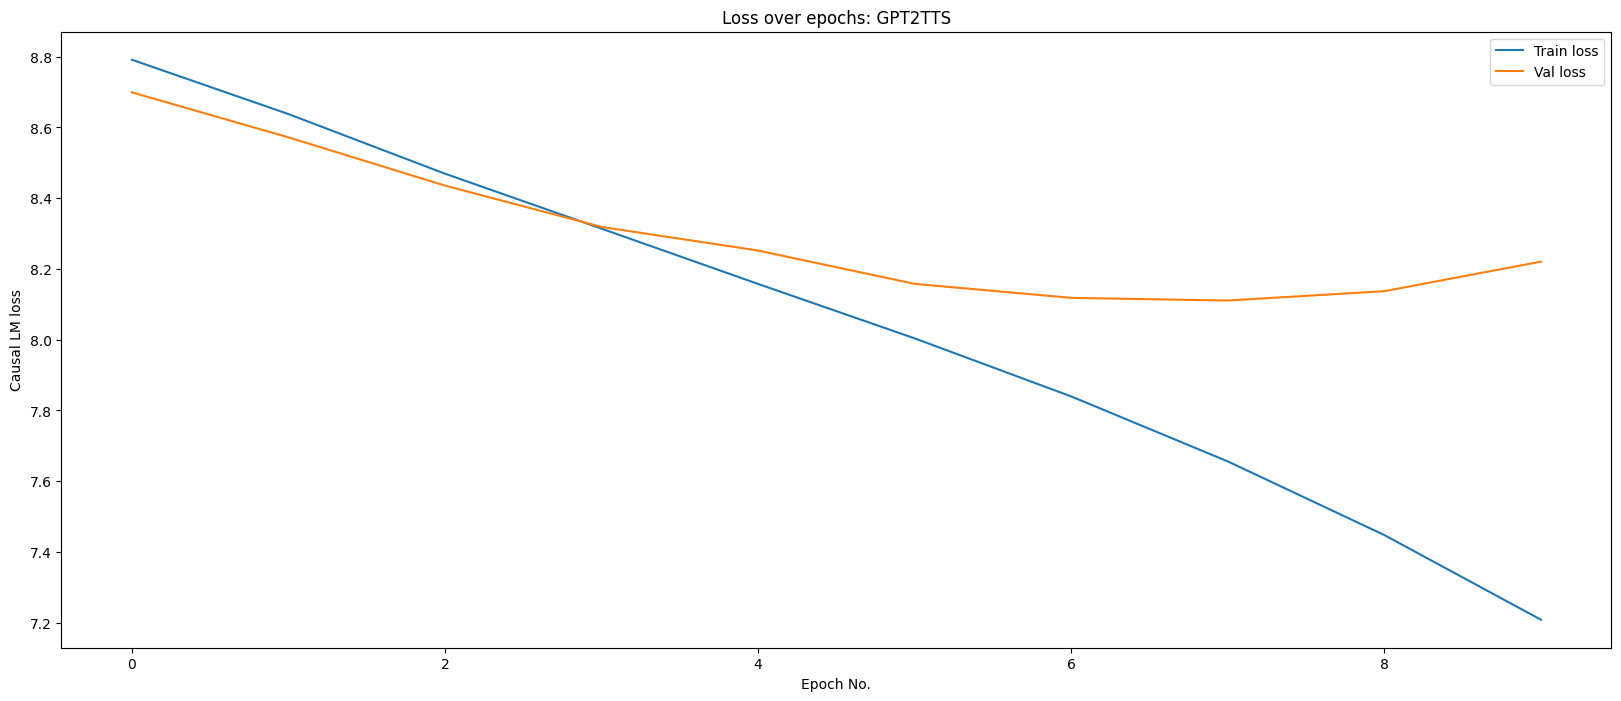

In [21]:
# train call
# tts.forward(**next(iter(train_dl)))
fig_loss, best_val_loss = train_and_get_stats_tts(
    model=tts,
    dls=dls,
    opt=opt,
    epochs_cnt=EPOCHS_CNT,
    device=device,
)

In [22]:
best_val_loss

8.110810170248987

### Resuming with less aggressive LR

In [19]:
state_dict = torch.load("/kaggle/input/models/antonk9021/gpttts/pytorch/default/1/GPT2TTS_best.pth", weights_only=True)
tts.load_state_dict(state_dict)
tts.to(device)
device

'cuda'

In [20]:
EPOCHS_CNT = 20

opt = torch.optim.AdamW(
    tts.parameters(),
    lr=3e-5,
    weight_decay=0.01,
)

In [22]:
EPOCHS_CNT

20

Training GPT2TTS since 2026-05-05 14:41:09.363108
Epoch 1/20


100%|██████████| 175/175 [00:13<00:00, 12.68it/s]


Train loss: 7.656260
Val loss:   8.033725
Saved best model to GPT2TTS_best.pth
Epoch 2/20


100%|██████████| 175/175 [00:13<00:00, 12.90it/s]


Train loss: 7.543358
Val loss:   8.008561
Saved best model to GPT2TTS_best.pth
Epoch 3/20


...

Train loss: 6.533746
Val loss:   8.138110
No significant improvement: 8/10
Epoch 14/20


100%|██████████| 175/175 [00:13<00:00, 12.86it/s]


Train loss: 6.435095
Val loss:   8.165772
No significant improvement: 9/10
Epoch 15/20


100%|██████████| 175/175 [00:13<00:00, 12.86it/s]


Train loss: 6.337298
Val loss:   8.189716
No significant improvement: 10/10
Early stopping: no val loss improvement for 10 epochs
Training completed in 0:57:52.056864
Best val loss: 8.002119
Completed training and stats collection of GPT2TTS in 0:57:53.114956


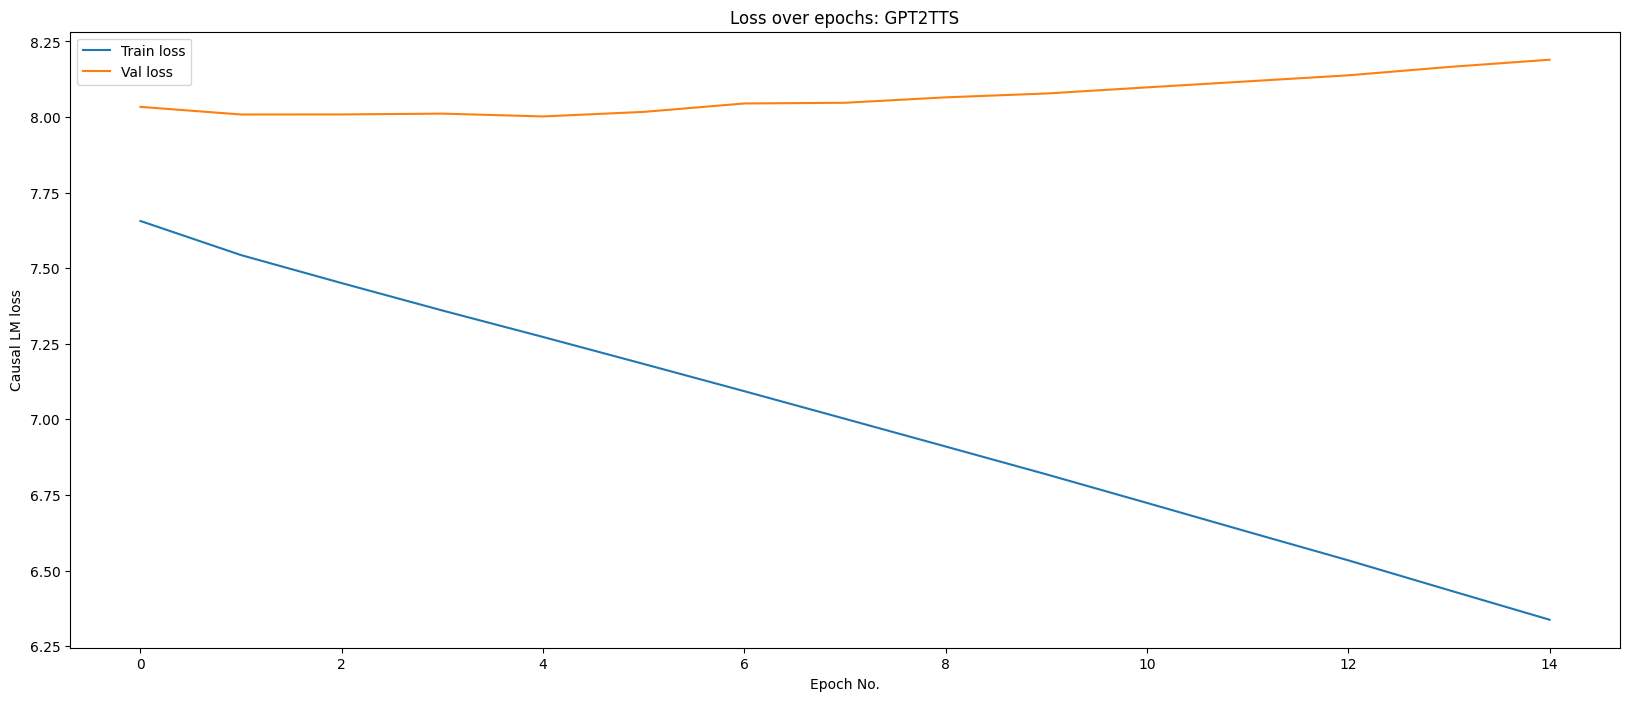

In [23]:
fig_loss, best_val_loss = train_and_get_stats_tts(
    model=tts,
    dls=dls,
    opt=opt,
    epochs_cnt=EPOCHS_CNT,
    device=device,
    patience=10
)

In [24]:
best_val_loss

8.00211850481438

The training has been early-stopped due to stale val loss progress. Possible fix: smaller learning rates; larger samples. 

# Inference

In [11]:
state_dict = torch.load("GPT2TTS_best.pth")
tts.load_state_dict(state_dict)
tts.to(device)

GPT2TTS(
  (base): GPT2LMHeadModel(
    (transformer): GPT2Model(
      (wte): Embedding(50257, 768)
      (wpe): Embedding(1024, 768)
      (drop): Dropout(p=0.1, inplace=False)
      (h): ModuleList(
        (0-11): 12 x GPT2Block(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): GPT2Attention(
            (c_attn): Conv1D(nf=2304, nx=768)
            (c_proj): Conv1D(nf=768, nx=768)
            (attn_dropout): Dropout(p=0.1, inplace=False)
            (resid_dropout): Dropout(p=0.1, inplace=False)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): GPT2MLP(
            (c_fc): Conv1D(nf=3072, nx=768)
            (c_proj): Conv1D(nf=768, nx=3072)
            (act): NewGELUActivation()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    )
    (lm_head): Linear(in_features=768, out_features=50257

In [13]:
# inference
text = "The quick brown fox jumps over the lazy dog."


def sample_tts(
    text, max_new=400, do_sample=False, temperature=0.9, top_k=10, top_p=1.0
):
    text_ids = torch.tensor(
        tokenizer.encode(text, add_special_tokens=False), device=device
    )
    toks = tts.generate_audio(
        text_ids,
        max_new_tokens=max_new,
        do_sample=do_sample,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
    )
    if toks.numel() == 0:
        return np.zeros(CODEC_SR // 2, dtype=np.float32), toks
    with torch.no_grad():
        wav = (
            codec.toks_to_sig(toks.unsqueeze(0))
            .squeeze(0)
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )
    return wav, toks


wav, toks = sample_tts(text)
print(f"{toks.numel()} tokens, {wav.shape[-1] / CODEC_SR:.2f}s")
print(f"  text: {text}")
# plot_mel(wav, CODEC_SR, f"{row['id']} (generated)")
display.display(display.Audio(wav, rate=CODEC_SR))

102 tokens, 4.08s
  text: The quick brown fox jumps over the lazy dog.


In [14]:
TEXTS = [
    'The quick brown fox jumps over the lazy dog',
    'To be, or not to be, that is the question',
]

decoding_strategies = {
    "greedy": {"do_sample": False, "top_k": 1},
    "topk10": {"do_sample": True, "top_k": 10},
    "topk100": {"do_sample": True, "top_k": 100},
    "topp10": {"do_sample": True, "top_p": 0.1},
    "topp90": {"do_sample": True, "top_p": 0.9},
}

for text in TEXTS:
    for strategy_name, params in decoding_strategies.items():
        print(f"{text} - {strategy_name}")
        wav, _ = sample_tts(text, **params)
        display.display(display.Audio(wav, rate=CODEC_SR))

The quick brown fox jumps over the lazy dog - greedy


The quick brown fox jumps over the lazy dog - topk10


The quick brown fox jumps over the lazy dog - topk100


The quick brown fox jumps over the lazy dog - topp10


The quick brown fox jumps over the lazy dog - topp90


To be, or not to be, that is the question - greedy


To be, or not to be, that is the question - topk10


To be, or not to be, that is the question - topk100


To be, or not to be, that is the question - topp10


To be, or not to be, that is the question - topp90


In [15]:
import torch
import torchaudio
import jiwer
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from speechbrain.inference.speaker import EncoderClassifier


def resample_audio(waveform, sample_rate, target_rate=16000):
    if sample_rate != target_rate:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sample_rate, new_freq=target_rate
        )
        waveform = resampler(waveform)
    # Convert stereo to mono if necessary
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    return waveform


class CerComputer:
    def __init__(self):
        model_id = "openai/whisper-base"
        self.processor = WhisperProcessor.from_pretrained(model_id)
        self.model = WhisperForConditionalGeneration.from_pretrained(model_id).to(
            device
        )

    def compute(self, wav_path: str, ref_text: str) -> float:
        def transcribe(audio_path):
            wav, sr = torchaudio.load(audio_path)
            wav = resample_audio(wav, sr, 16000).squeeze().numpy()
            input_features = self.processor(
                wav, sampling_rate=16000, return_tensors="pt"
            ).input_features.to(device)
            predicted_ids = self.model.generate(
                input_features,
                forced_decoder_ids=self.processor.get_decoder_prompt_ids(
                    language="en", task="transcribe"
                ),
            )
            return self.processor.batch_decode(predicted_ids, skip_special_tokens=True)[
                0
            ]

        hypothesis_text = transcribe(wav_path)

        transform = jiwer.Compose(
            [
                jiwer.ToLowerCase(),
                jiwer.RemovePunctuation(),
                jiwer.Strip(),
                jiwer.RemoveMultipleSpaces(),
            ]
        )

        truth_clean = transform(ref_text)
        hypothesis_clean = transform(hypothesis_text)
        return jiwer.cer(truth_clean, hypothesis_clean)


class UtmosComputer:
    def __init__(self):
        self.predictor = torch.hub.load(
            "tarepan/SpeechMOS:v1.2.0", "utmos22_strong"
        ).to(device)

    def compute(self, synth_wav_path: str) -> float:
        wav, sr = torchaudio.load(synth_wav_path)
        wav = resample_audio(wav, sr, 16000).to(device)

        with torch.no_grad():
            score = self.predictor(wav, 16000)

        return score.item()


class SecsComputer:
    def __init__(self):
        self.classifier = EncoderClassifier.from_hparams(
            source="speechbrain/spkrec-ecapa-voxceleb",
            savedir="tmpdir",
        ).to(device)

    def compute(self, ref_wav_path: str, synth_wav_path: str) -> float:
        def get_embedding(audio_path):
            wav, sr = torchaudio.load(audio_path)
            wav = resample_audio(wav, sr, 16000).squeeze(0)
            with torch.no_grad():
                embedding = self.classifier.encode_batch(wav)
            return embedding.squeeze()

        emb_ref = get_embedding(ref_wav_path)
        emb_synth = get_embedding(synth_wav_path)

        cos_sim = torch.nn.functional.cosine_similarity(emb_ref, emb_synth, dim=0)

        return cos_sim.item()

In [16]:
from scipy.io import wavfile
from tqdm import tqdm


def write_tmp_wav(wav):
    wavfile.write("tmp.wav", CODEC_SR, wav.astype(np.float32))


cer_computer = CerComputer()
utmos_computer = UtmosComputer()
secs_computer = SecsComputer()

metrics = []
val_df_sample = val_df.iloc[:100]

for _, row in tqdm(val_df_sample.iterrows(), total=len(val_df_sample)):
    wav, _ = sample_tts(row["text"], max_new=400, do_sample=False, top_k=1)
    write_tmp_wav(wav)

    cer = cer_computer.compute("tmp.wav", row["text"])
    utmos = utmos_computer.compute("tmp.wav")
    secs = secs_computer.compute(row["filepath"], "tmp.wav")

    metrics.append({"cer": cer, "utmos": utmos, "secs": secs})

METRICS = ['cer', 'utmos', 'secs']
for metric in METRICS:
    print(metric, np.mean([m[metric] for m in metrics]))

Using cache found in /home/user/.cache/torch/hub/tarepan_SpeechMOS_v1.2.0
Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.
  0%|          | 0/100 [00:00<?, ?it/s]Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
100%|██████████| 100/100 [01:30<00:00,  1.10it/s]

cer 1.5574488401888693
utmos 2.537487790584564
secs 0.24971895061433316


# Homework

Theory:
Answer theory questions in the Google Form.

Practice:

1. Complete the gptTTS code 
1. Put together training pipeline with torch or lightning 
1. Train gpt2 for TTS task
1. Run inference with different sampling strategies on several texts
1. Compute CER; UTMOS; SECS from xTTS paper (you can use xTTS's library)